In [1]:
# %matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# The 1D Ideal MHD Equations

\begin{equation}\tag{1}
\mathbf{U}_t + \mathbf{F}(\mathbf{U})_x = 0
\end{equation}


\begin{equation}\tag{2}
\mathbf{U} =
\begin{pmatrix}
\rho \\
\rho u_x \\
\rho u_y \\
\rho u_z \\
E \\
B_x \\
B_y \\
B_z \\
\end{pmatrix},
\qquad
\mathbf{F}(\mathbf{U}) =
\begin{pmatrix}
\rho u_x \\
\rho u_x^2 + p + \frac{1}{2}\|\mathbf{B}\|^2 - B_x^2 \\
\rho u_x u_y - B_x B_y \\
\rho u_x u_z - B_x B_z \\
u_x \left(E + p + \frac{1}{2}\|\mathbf{B}\|^2 \right) - B_x (\mathbf{u}\cdot\mathbf{B}) \\
0 \\
u_x B_y - u_y B_x \\
u_x B_z - u_z B_x 
\end{pmatrix}
\end{equation}

The conserved variables are:

- mass density: $\rho(x,t)$  
- momentum density: $\rho \textbf{u} (x,t)  = (\rho u_x, \rho u_y, \rho u_z)$  
- energy density: $E(x,t)$ 
- magnetic field: $\textbf{B}(x,t) = (B_x, B_y, B_z)$  

The primitive (physical) variables are:

- density: $\rho(x,t)$  
- velocity: $\textbf{u}(x,t) = (u_x, u_y, u_z)$  
- pressure: $p(x,t)$ 
- magnetic field: $\textbf{B}(x,t) = (B_x, B_y, B_z)$  

The total energy density is given as:

\begin{equation}\tag{3}
E = \frac{p}{\gamma - 1} + \frac{1}{2} \rho \|\mathbf{u}\|^2  + \frac{1}{2} \|\mathbf{B}\|^2
\end{equation}

where $\gamma$ is the adiabatic index

# $\Downarrow$ Edit These Functions $\Downarrow$

- get_primitive_from_conserved
- get_conserved_from_primitive
- get_flux
- hll_riemann_solver

In [2]:
def get_primitive_from_conserved(q_sys,gamma):
    ''' 
    Definition: converts our conserved variables to primitive

    Inputs:     conserved variables: q_sys = (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T
                gamma: adiabatic index

    Outputs:    primitive variables: w_sys = (ρ,  u_x,  u_y,  u_z, p, Bx, By, Bz)^T
                    
    Dependencies: none
    '''

    w_sys = np.zeros_like(q_sys)

    rho = q_sys[0]
    vex = q_sys[1] / rho
    vey = q_sys[2] / rho
    vez = q_sys[3] / rho
    E   = q_sys[4]
    Bx  = q_sys[5]
    By  = q_sys[6]
    Bz  = q_sys[7]

    KE = 0.5 * rho * ( vex**2. + vey**2. + vez**2. )
    ME = 0.5 * ( Bx**2. + By**2. + Bz**2.)

    pre = (gamma - 1.) * (E - KE - ME) 
    
    w_sys[0] = rho
    w_sys[1] = vex
    w_sys[2] = vey   
    w_sys[3] = vez
    w_sys[4] = pre
    w_sys[5] = Bx
    w_sys[6] = By
    w_sys[7] = Bz

    return w_sys

In [3]:
def get_conserved_from_primitive(w_sys,gamma):
    ''' 
    Definition: converts our primitive variables to conserved 

    Inputs:     primitive variables: w_sys = (ρ,  u_x,  u_y,  u_z, p, Bx, By, Bz)^T
                gamma: adiabatic index

    Outputs:    conserved variables: q_sys = (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T
                    
    Dependencies: none
    '''

    q_sys = np.zeros_like(w_sys)

    rho = w_sys[0]
    vex = w_sys[1] 
    vey = w_sys[2] 
    vez = w_sys[3] 
    pre = w_sys[4]
    Bx  = w_sys[5]
    By  = w_sys[6]
    Bz  = w_sys[7]

    KE = 0.5 * rho * ( vex**2. + vey**2. + vez**2. )
    ME = 0.5 * ( Bx**2. + By**2. + Bz**2.)

    E = (pre / (gamma - 1.)) + KE + ME  
    
    q_sys[0] = rho
    q_sys[1] = vex * rho
    q_sys[2] = vey * rho   
    q_sys[3] = vez * rho
    q_sys[4] = E 
    q_sys[5] = Bx
    q_sys[6] = By
    q_sys[7] = Bz

    return q_sys

In [4]:
def get_flux(q_sys, gamma):
    '''
    Definition: computes F(U) for our conservation equation
                U_t + [F(U)]_x = 0

    Inputs:     conserved variables: q_sys = (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T
                gamma: adiabatic index

    Outputs:    flux f(q):

           |              ρu_x                |
           | ρu_xu_x + p + 0.5*∥B∥^2 - B_xB_x  |
           |        ρu_xu_y - B_xB_y          |
    f(q) = |        ρu_xu_z - B_xB_z          |
           | u_x(E + p + 0.5*∥B∥^2) - B_x(u·B) |
           |               0                  |
           |        u_xB_y - u_yB_x           |
           |        u_xB_z - u_zB_x           |

    Dependencies: none
    '''

    flux_sys = np.zeros_like(q_sys)

    rho = q_sys[0]
    vex = q_sys[1] / rho
    vey = q_sys[2] / rho
    vez = q_sys[3] / rho
    E   = q_sys[4]
    Bx  = q_sys[5]
    By  = q_sys[6]
    Bz  = q_sys[7]

    ME = 0.5 * ( Bx**2. + By**2. + Bz**2.)
    KE = 0.5 * rho * ( vex**2. + vey**2. + vez**2. )

    pre = (gamma - 1.) * (E - KE - ME ) 

    u_dot_B = vex*Bx + vey*By + vez*Bz

    flux_sys[0] = rho * vex        
    flux_sys[1] = rho * vex * vex + pre + ME - Bx * Bx
    flux_sys[2] = rho * vex * vey - Bx * By
    flux_sys[3] = rho * vex * vez - Bx * Bz
    flux_sys[4] = vex * (E + pre + ME) - Bx * (u_dot_B) 
    flux_sys[5] = 0
    flux_sys[6] = vex * By - vey * Bx
    flux_sys[7] = vex * Bz - vez * Bx                  
    
    return flux_sys 

In [5]:
def hll_riemann_solver(w_l, w_r, gamma):
    '''
    Definition: Computes the HLL approximate Riemann flux for ideal MHD

    Inputs:     w_l :  left primitive state (ρ_l,  u_x_l,  u_y_l,  u_z_l, p_l, Bx_l, By_l, Bz_l)^T
                w_r : right primitive state (ρ_r,  u_x_r,  u_y_r,  u_z_r, p_r, Bx_r, By_r, Bz_r)^T
                gamma: adiabatic index

    Outputs:    HLL flux vector corresponding to conserved variables: (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T

    Dependencies: get_conserved_from_primitive, get_flux

    See Chapter 10 The HLL and HLLC Riemann Solvers in the book 
    Riemann Solvers and Numerical Methods for Fluid Dynamics by Eleuterio F. Toro

                 t
                 ^
                 |
        s_l      |      s_r
          \ (--u_hll--) /
           \     |     /
            \    |    /
             \   |   /
      u_l     \  |  /     u_r
               \ | /
                \|/
  ---------------+-----------------> x
                 0

    '''

    ################################################################################################
    # 1) Start with Reconstructed Primitive Variables (Equation 10.6)
    ################################################################################################

    rho_l = w_l[0]
    vex_l = w_l[1]    
    vey_l = w_l[2] 
    vez_l = w_l[3] 
    pre_l = w_l[4] 
    Bx_l  = w_l[5] 
    By_l  = w_l[6] 
    Bz_l  = w_l[7] 

    rho_r = w_r[0]
    vex_r = w_r[1]    
    vey_r = w_r[2] 
    vez_r = w_r[3] 
    pre_r = w_r[4] 
    Bx_r  = w_r[5] 
    By_r  = w_r[6] 
    Bz_r  = w_r[7] 

    ################################################################################################
    # 2) Compute Fastest Wave Speed (Fast Magnetosonic)
    ################################################################################################

    # a^2 (Sound Speed) 
    a2_l = gamma * pre_l / rho_l
    a2_r = gamma * pre_r / rho_r
    
    # ∥B∥^2 (Magnetic Field Magnitude)
    B2_l = Bx_l**2 + By_l**2 + Bz_l**2
    B2_r = Bx_r**2 + By_r**2 + Bz_r**2

    # Term 1 = a^2 + ∥B∥^2/ρ
    term1_l = a2_l + B2_l / rho_l
    term1_r = a2_r + B2_r / rho_r

    # Term 2 = sqrt( term1^2 - 4 * a^2 * (Bx^2 / ρ) )
    term2_l = np.sqrt(term1_l**2 - 4.0 * a2_l * (Bx_l**2) / rho_l)
    term2_r = np.sqrt(term1_r**2 - 4.0 * a2_r * (Bx_r**2) / rho_r)

    # c_f (Fast Magnetosonic Wave Speed )
    cf_l = np.sqrt(0.5 * (term1_l + term2_l))
    cf_r = np.sqrt(0.5 * (term1_r + term2_r))

    ################################################################################################
    # 3) Determine Leftmost and Rightmost Eigenvalues (See Fig. 10.1)
    ################################################################################################

    s_l = min(vex_l - cf_l, vex_r - cf_r)
    s_r = max(vex_l + cf_l, vex_r + cf_r)

    ################################################################################################
    # 4) Obtain the Conserved States & Fluxes (See Equation 10.17, 10.21)
    ################################################################################################

    u_l = get_conserved_from_primitive(w_l,gamma)
    u_r = get_conserved_from_primitive(w_r,gamma)

    f_l = get_flux(u_l, gamma)
    f_r = get_flux(u_r, gamma)

    ################################################################################################
    # 5) Determine the HLL Flux (Equation 10.21)
    ################################################################################################

    if s_l >= 0:
        flux = f_l
    elif s_r <= 0:
        flux = f_r
    else:
        flux = (s_r * f_l - s_l * f_r + s_l * s_r * (u_r - u_l)) / (s_r - s_l)

    return flux

# $\Downarrow$ No Need To Edit - Run These Cells $\Downarrow$

In [6]:
def minmod(a, b):
    '''
               b > 0       b = 0       b < 0
    ---------------------------------------------
    a > 0 |   min(a,b)       0           0
    a = 0 |      0           0           0
    a < 0 |      0           0      -min(|a|,|b|)
    '''
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))


def PLM(w_im1, w_i, w_ip1):
    '''
    Definition: computes piecewise linear method (PLM) reconstruction
    
    Inputs:     primitive state at cells i-1, i, and i+1

    Outputs:    w_{i+1/2}^- (left state at right interface)

    Dependencies: none

    '''
    delta_minus = w_i   - w_im1 # slope to the left of cell i (backward difference) 
    delta_plus  = w_ip1 - w_i   # slope to the right of cell i (forward difference)

    slope = minmod(delta_minus, delta_plus) # picks the smaller slope to prevent overshoot near sharp gradients

    # Returns the reconstructed value at the left side of the right interface of cell i
    # w_i: baseline (cell center i)
    # 0.5 * slope: extrapolation to the interface i+1/2
    return w_i + 0.5 * slope

In [7]:
def initial_condition(case, grid):
    '''
    Definition: loads initial conditions for classic 1D Riemann Problems

    Inputs:     case: various 1D test cases defined below
                grid: spatial domain

    Outputs:    conserved variables q_sys = (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T
                gamma: adiabatic index
                tf: final time

    Dependencies: none
    '''

    q_sys = np.zeros((8,len(grid))) 

    # w_l and w_r are primitive variables

    if case == 'Sod':
        #             ([    ρ, u_x, u_y, u_z,   p, B_x, B_y, B_z])
        w_l = np.array([  1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0])
        w_r = np.array([0.125, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0])
        
        gamma = 1.4  # Heat Capacity Ratio
        tf = 0.1     # Final Time

    if case == 'Reverse Sod':
        #             ([    ρ, u_x, u_y, u_z,   p, B_x, B_y, B_z])
        w_l = np.array([0.125, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0])
        w_r = np.array([  1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0])
        
        gamma = 1.4  # Heat Capacity Ratio
        tf = 0.1     # Final Time

    elif case == 'Brio-Wu':
        #             ([    ρ, u_x, u_y, u_z,   p, B_x,   B_y, B_z])
        w_l = np.array([  1.0, 0.0, 0.0, 0.0, 1.0, 0.75,  1.0, 0.0])
        w_r = np.array([0.125, 0.0, 0.0, 0.0, 0.1, 0.75, -1.0, 0.0])
        
        gamma = 2.0  # Heat Capacity Ratio
        tf = 0.1     # Final Time
 
    elif case == 'Reverse Brio-Wu':
        #             ([    ρ, u_x, u_y, u_z,   p, B_x,   B_y, B_z])
        w_l = np.array([0.125, 0.0, 0.0, 0.0, 0.1, 0.75, -1.0, 0.0])
        w_r = np.array([  1.0, 0.0, 0.0, 0.0, 1.0, 0.75,  1.0, 0.0])
        
        gamma = 2.0  # Heat Capacity Ratio
        tf = 0.1     # Final Time

    if case == 'Dai-Woodward':
        #             ([    ρ, u_x,  u_y, u_z,    p,                B_x,                  B_y,                B_z])
        w_l = np.array([ 1.08, 1.2, 0.01, 0.5, 0.95, 2/np.sqrt(4*np.pi), 3.6/np.sqrt(4*np.pi), 2/np.sqrt(4*np.pi)])
        w_r = np.array([  1.0, 0.0,  0.0, 0.0,  1.0, 2/np.sqrt(4*np.pi),   4/np.sqrt(4*np.pi), 2/np.sqrt(4*np.pi)])
        
        gamma = 5/3  # Heat Capacity Ratio        
        tf = 0.2     # Final Time

    if case == 'Reverse Dai-Woodward':
        # Reverse Dai & Woodward
        #             ([    ρ,  u_x,   u_y,  u_z,    p,                B_x,                  B_y,                B_z])
        w_l = np.array([  1.0,  0.0,   0.0,  0.0,  1.0, 2/np.sqrt(4*np.pi),   4/np.sqrt(4*np.pi), 2/np.sqrt(4*np.pi)])
        w_r = np.array([ 1.08, -1.2, -0.01, -0.5, 0.95, 2/np.sqrt(4*np.pi), 3.6/np.sqrt(4*np.pi), 2/np.sqrt(4*np.pi)])
        
        gamma = 5/3  # Heat Capacity Ratio     
        tf = 0.2     # Final Time

    # define where the Riemann problem begins on our grid
    xdiscont = 0.5

    left = (grid < xdiscont) 
    right = (grid >= xdiscont)

    # Left States (conserved variables)
    q_sys[0,left] = w_l[0]
    q_sys[1,left] = w_l[0] * w_l[1]
    q_sys[2,left] = w_l[0] * w_l[2]
    q_sys[3,left] = w_l[0] * w_l[3]
    q_sys[4,left] = (w_l[4] / ((gamma-1.))) + 0.5 * w_l[0] * (w_l[1]**2 + w_l[2]**2 + w_l[3]**2) + 0.5 * (w_l[5]**2 + w_l[6]**2 + w_l[7]**2)
    q_sys[5,left] = w_l[5]
    q_sys[6,left] = w_l[6]
    q_sys[7,left] = w_l[7]

    # Right States (conserved variables)
    q_sys[0,right] = w_r[0]
    q_sys[1,right] = w_r[0] * w_r[1]
    q_sys[2,right] = w_r[0] * w_r[2]
    q_sys[3,right] = w_r[0] * w_r[3]
    q_sys[4,right] = (w_r[4] / ((gamma-1.))) + 0.5 * w_r[0] * (w_r[1]**2 + w_r[2]**2 + w_r[3]**2) + 0.5 * (w_r[5]**2 + w_r[6]**2 + w_r[7]**2)
    q_sys[5,right] = w_r[5]
    q_sys[6,right] = w_r[6]
    q_sys[7,right] = w_r[7]

    return q_sys, gamma, tf

In [8]:
def boundary_conditions(q_sys,n_ghost):
    '''
    Definition: updates boundary conditions based on the type
                "periodic" or "reflective"

    Inputs:     conserved variables: q_sys = (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T
                n_ghost: number of ghost cells

    Outputs:    updated q_sys based on boundary conditions

    If we have the domain of grid cells denoted by |-----|, where |~~~~~| signifies ghost cells

      [0]   [1]   [2]   [3]         [.]         [N]  [N+1] [N+2] [N+3]
	|~~~~~|~~~~~|-----|-----|-----|-----|-----|-----|-----|~~~~~|~~~~~|

    Our swap for periodic boundary conditions is as follows:
    q_sys[0] = q_sys[N] 
    q_sys[1] = q_sys[N+1]
    q_sys[N+2] = q_sys[2]
    q_sys[N+3] = q_sys[3]    

    Our swap for reflective boundary conditions is as follows:
    q_sys[0] = q_sys[2]
    q_sys[1] = q_sys[3]
    q_sys[N+2] = q_sys[N]
    q_sys[N+3] = q_sys[N+1]    

    Dependencies: none
    '''

    # Periodic Boundary Conditions
    # for i in range(n_ghost):
    #     q_sys[:,i] = q_sys[:,-2*n_ghost+i]
    #     q_sys[:,-1*n_ghost+i] = q_sys[:,n_ghost+i]

    # Reflective Boundary Conditions
    for i in range(n_ghost):
        q_sys[:,i] = q_sys[:,n_ghost+i]
        q_sys[:,-1*n_ghost+i] = q_sys[:,-2*n_ghost+i]
        
    return q_sys

In [9]:
def eigenvalues(q_sys,gamma):

    em = 1.0e-15

    # 1) Convert our Conserved Variables q_sys = [ρ, ρu_x, ρu_y, ρu_z, E, B_x, B_y, B_z]^T 
    # ...     to our Primitive Variables w_sys = [ρ,  u_x,  u_y,  u_z, p, B_x, B_y, B_z]^T
   
    all_rho = q_sys[0, :]
    all_vex = q_sys[1, :] / q_sys[0, :]
    all_vey = q_sys[2, :] / q_sys[0, :]
    all_vez = q_sys[3, :] / q_sys[0, :]
    all_E   = q_sys[4, :]
    all_Bx  = q_sys[5, :]
    all_By  = q_sys[6, :]
    all_Bz  = q_sys[7, :]
    all_pre = (gamma-1.)*(all_E - 0.5*all_rho*(all_vex**2 + all_vey**2 + all_vez**2) - 0.5*(all_Bx**2 + all_By**2 + all_Bz**2))

    # 2) Compute Sound Speed
    a = np.sqrt(gamma * all_pre / all_rho)

    # 3) Compute Alfven Wave Speed
    ca  = np.sqrt((all_Bx**2 + all_By**2 + all_Bz**2) / all_rho)
    cax = np.abs(np.sqrt(all_Bx**2 / all_rho))

    # 4) Compute Fast Magnetosonic Wave Speed
    cf = np.sqrt(0.5 * np.abs( a**2 + ca**2 + np.sqrt((a**2 + ca**2)**2 - (4 * a**2 * cax**2))))

    # 5) Compute Slow Magnetosonic Wave Speed
    cs = np.sqrt(0.5 * np.abs( a**2 + ca**2 - np.sqrt((a**2 + ca**2)**2 - (4 * a**2 * cax**2))))

    # 6) Find Maximum Wave Speed
    max_eigen_1 = max(em, np.max(np.abs(all_vex - cf )))
    max_eigen_2 = max(em, np.max(np.abs(all_vex - cax)))
    max_eigen_3 = max(em, np.max(np.abs(all_vex - cs )))
    max_eigen_4 = max(em, np.max(np.abs(all_vex      )))
    max_eigen_5 = max(em, np.max(np.abs(all_vex      )))
    max_eigen_6 = max(em, np.max(np.abs(all_vex + cs )))
    max_eigen_7 = max(em, np.max(np.abs(all_vex + cax)))
    max_eigen_8 = max(em, np.max(np.abs(all_vex + cf )))

    alpha = np.array([max_eigen_1, max_eigen_2 , max_eigen_3, max_eigen_4, max_eigen_5, max_eigen_6, max_eigen_7, max_eigen_8])

    return alpha

In [10]:
def plot_solution(grid, q_sys, t, gamma, case):
    '''
    Definition: plots density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid  : array of x coordinates
                q_sys : conserved variables (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T
                t     : current time
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    matplotlib figure showing MHD quantities

    Dependencies: get_primitive_from_conserved 
    '''

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)

    rho, vex, vey, vez, pre, Bx, By, Bz = get_primitive_from_conserved(q_sys, gamma)
    E = q_sys[4]
    
    fig, plots = plt.subplots(2, 3, figsize=(18, 8), dpi=300)

    fig.suptitle(f'{case} Shock Tube at t = {t:.2f}')

    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.color'] = 'lavender'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 0.8

    CE = 'k' 
    CS = 'mediumslateblue' 

    # Top Left Plot
    plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2)
    plots[0][0].plot(grid, rho, color=CS, linestyle='-', linewidth=1.5)
    plots[0][0].set_title('Density')
    plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 

    # Bottom Left Plot
    plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
    plots[1][0].plot(grid, pre, color=CS, linestyle='-', linewidth=1.5)
    plots[1][0].set_title('Pressure')
    plots[1][0].set_xlim([0,1]);# plots[0][1].set_ylim([0.0,1.05])

    # Top Middle Plot
    plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
    plots[0][1].plot(grid, vex, color=CS, linestyle='-', linewidth=1.5)
    plots[0][1].set_title(r'$v_x$')
    plots[0][1].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

    # Bottom Middle Plot
    plots[1][1].plot(exact_grid, exact_vey, color=CE, linestyle='-', linewidth=2)
    plots[1][1].plot(grid, vey, color=CS, linestyle='-', linewidth=1.5)
    plots[1][1].set_title(r'$v_y$')
    plots[1][1].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])

    # Top Right Plot
    plots[0][2].plot(exact_grid, exact_By, color=CE, linestyle='-', linewidth=2)
    plots[0][2].plot(grid, By, color=CS, linestyle='-', linewidth=1.5)
    plots[0][2].set_title(r'$B_y$')
    plots[0][2].set_xlim([0,1]);# plots[2][1].set_ylim([-1.2,1.2])

    # Bottom Right Plot
    plots[1][2].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
    plots[1][2].plot(grid, E, color=CS, linestyle='-', linewidth=1.5)
    plots[1][2].set_title('Total Energy')
    plots[1][2].set_xlim([0,1]);# plots[0][2].set_ylim([0.7,2.0])

    # plt.savefig(f"{case}.png",dpi=200)

    plt.show()

In [11]:
def movie_maker(grid, all_solns, all_t, gamma, case):
    '''
    Definition: creates a movie of the 1D MHD solution: 
                density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid      : array of x coordinates
                all_solns : array of conserved variables (ρ, ρu_x, ρu_y, ρu_z, E, Bx, By, Bz)^T at all time steps
                all_t     : array of all time steps
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    movie showing MHD quantities

    Dependencies: get_primitive_from_conserved
    '''

    n_steps = len(all_t)

    # Create a figure and axis for plotting
    fig, plots = plt.subplots(2, 3, figsize=(18, 8), dpi=200)

    def animate(i):
        ''' function to update the plot for each frame  '''

        plots[0][0].clear()
        plots[1][0].clear()
        plots[0][1].clear()
        plots[1][1].clear()
        plots[0][2].clear()
        plots[1][2].clear()

        q_sys = all_solns[i]
        t = all_t[i]

        exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)

        rho, vex, vey, vez, pre, Bx, By, Bz = get_primitive_from_conserved(q_sys, gamma)
        E = q_sys[4]
        
        fig.suptitle(f'{case} Shock Tube at t = {t:.3f}')

        plt.rcParams['axes.grid'] = True
        plt.rcParams['grid.color'] = 'lavender'
        plt.rcParams['grid.linestyle'] = '-'
        plt.rcParams['grid.linewidth'] = 0.8

        CE = 'k' 
        CS = 'mediumslateblue' 

        # Top Left Plot
        plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2)
        plots[0][0].plot(grid, rho, color=CS, linestyle='-', linewidth=1.5)
        plots[0][0].set_title('Density')
        plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 

        # Bottom Left Plot
        plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
        plots[1][0].plot(grid, pre, color=CS, linestyle='-', linewidth=1.5)
        plots[1][0].set_title('Pressure')
        plots[1][0].set_xlim([0,1]);# plots[0][1].set_ylim([0.0,1.05])

        # Top Middle Plot
        plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
        plots[0][1].plot(grid, vex, color=CS, linestyle='-', linewidth=1.5)
        plots[0][1].set_title(r'$v_x$')
        plots[0][1].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

        # Bottom Middle Plot
        plots[1][1].plot(exact_grid, exact_vey, color=CE, linestyle='-', linewidth=2)
        plots[1][1].plot(grid, vey, color=CS, linestyle='-', linewidth=1.5)
        plots[1][1].set_title(r'$v_y$')
        plots[1][1].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])

        # Top Right Plot
        plots[0][2].plot(exact_grid, exact_By, color=CE, linestyle='-', linewidth=2)
        plots[0][2].plot(grid, By, color=CS, linestyle='-', linewidth=1.5)
        plots[0][2].set_title(r'$B_y$')
        plots[0][2].set_xlim([0,1]);# plots[2][1].set_ylim([-1.2,1.2])

        # Bottom Right Plot
        plots[1][2].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
        plots[1][2].plot(grid, E, color=CS, linestyle='-', linewidth=1.5)
        plots[1][2].set_title('Total Energy')
        plots[1][2].set_xlim([0,1]);# plots[0][2].set_ylim([0.7,2.0])

    # Create the animation using matplotlib's FuncAnimation
    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=1, blit=False)
    
    # Save the animation as a video file
    ani.save(f"{case}.mp4", dpi=200)

# $\Downarrow$ Main Code Below $\Downarrow$

Step: 100, Time: 0.005
Step: 200, Time: 0.011
Step: 300, Time: 0.016
Step: 400, Time: 0.021
Step: 500, Time: 0.026
Step: 600, Time: 0.031
Step: 700, Time: 0.036
Step: 800, Time: 0.041
Step: 900, Time: 0.046
Step: 1000, Time: 0.052
Step: 1100, Time: 0.057
Step: 1200, Time: 0.062
Step: 1300, Time: 0.067
Step: 1400, Time: 0.072
Step: 1500, Time: 0.077
Step: 1600, Time: 0.082
Step: 1700, Time: 0.088
Step: 1800, Time: 0.093
Step: 1900, Time: 0.098
Finished at Step: 1944, Time: 0.100


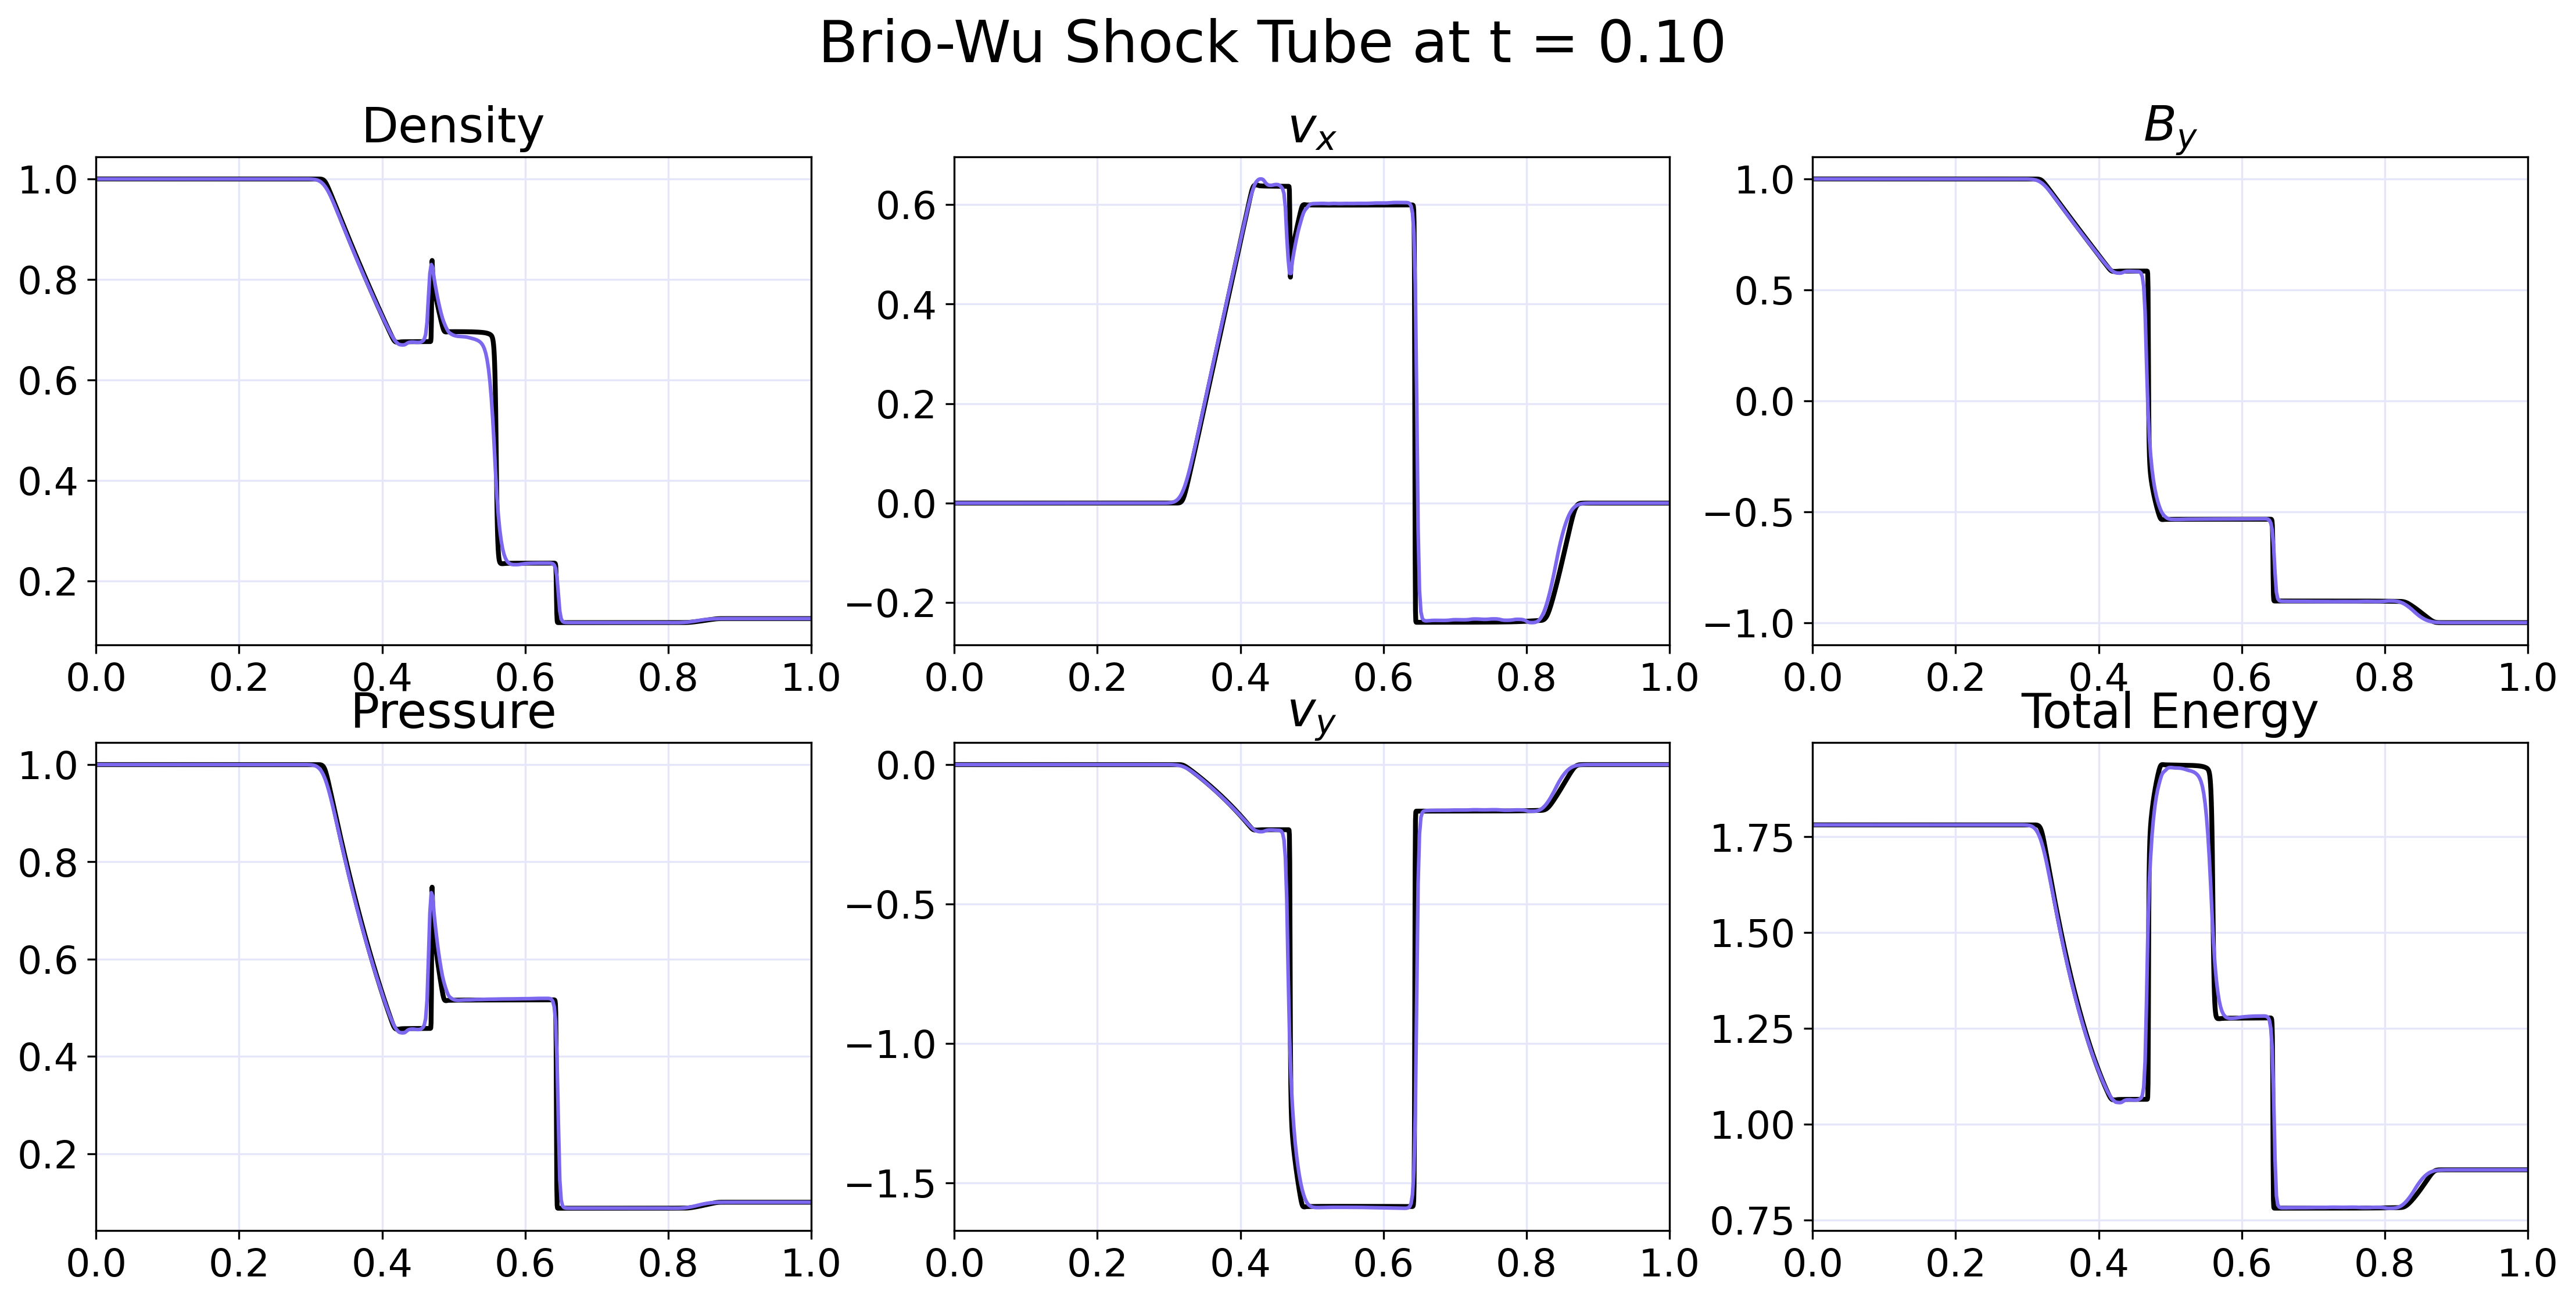

In [13]:
####################################################################################################
# Input Data
####################################################################################################

# Spatial Domain
x_min = 0.0; x_max = 1.0

# Number of Spatial Itterations
# n_points = 1024
# n_points = 512
n_points = 512

# Number of Ghost Cells
n_ghost = 2

# Step Size ∆x
dx = (x_max-x_min)/(n_points)

# Spatial Domain Grid (Including Ghosst Cells)
grid = np.linspace(x_min - n_ghost * dx, x_max - dx + n_ghost * dx, n_points + 2 * n_ghost)

# Courant-Friedrichs-Lewy (CFL) condition
CFL = 0.1

####################################################################################################
# Define Our Test Problem
####################################################################################################

# case = 'Sod'
# case = 'Reverse Sod'
case = 'Brio-Wu'
# case = 'Reverse Brio-Wu'
# case = 'Dai-Woodward'
# case = 'Reverse Dai-Woodward'

####################################################################################################
# Generate Initial Data
###################################################################################################

q_sys, gamma, tf = initial_condition(case, grid)

q_sys_new = q_sys.copy()

####################################################################################################
# Time Advance
####################################################################################################

t = 0

all_solns = []
all_t = []

# Append q_sys, t for making a movie 
all_solns.append(q_sys[:,n_ghost:-n_ghost])
all_t.append(t)

# plot_solution(grid[n_ghost:-n_ghost], q_sys[:,n_ghost:-n_ghost], 0.0, gamma, case)

nt = 0  # Initialize a Time Step Counter

while t < tf:


    ################################################################################################
    # Update Boundary Conditions
    ################################################################################################
    
    q_sys = boundary_conditions(q_sys,n_ghost)

    w_sys = get_primitive_from_conserved(q_sys,gamma)

    ################################################################################################
    # Estimate Time Step
    ################################################################################################
    
    # 1) Compute Eigenvalues
    alpha = eigenvalues(q_sys,gamma)

    # 2) Find Maximum Wave Speed
    max_speed = max(alpha)

    # 3) Compute Time Step
    dt = CFL * dx / max_speed

    # 4) Stops our dt from going past tf
    if t + dt > tf:
        dt = tf - t

    ################################################################################################
    # Update Fluxes
    ################################################################################################
    
    for i in range(n_ghost,(n_points)+n_ghost): # Loop Over Domain x ∈ [0,1]

        wlm = PLM(w_sys[:,i-2], w_sys[:,i-1], w_sys[:,i]) # Reconstruction of U_{i-1/2}^- 
        wlp = PLM(w_sys[:,i+1], w_sys[:,i], w_sys[:,i-1]) # Reconstruction of U_{i-1/2}^+

        wrm = PLM(w_sys[:,i-1], w_sys[:,i], w_sys[:,i+1]) # Reconstruction of U_{i+1/2}^-
        wrp = PLM(w_sys[:,i+2], w_sys[:,i+1], w_sys[:,i]) # Reconstruction of U_{i+1/2}^+

        left_interface_flux  = hll_riemann_solver(wlm, wlp, gamma) # F(U_{i-1/2}) = Riemann_Solver( U_{i-1/2}^- , U_{i-1/2}^+ )
        right_interface_flux = hll_riemann_solver(wrm, wrp, gamma) # F(U_{i+1/2}) = Riemann_Solver( U_{i+1/2}^- , U_{i+1/2}^+ )    

        q_sys_new[:, i] = q_sys[:, i] - (dt/dx)*(right_interface_flux - left_interface_flux) # U_i^{n+1} = U_i^n - (∆t/∆x) ( F_{i+1/2}^{n+1/2} - F_{i-1/2}^{n+1/2} )
    

    q_sys = np.copy(q_sys_new)
    
    t += dt # Update Current Time 

    nt += 1  # Increment Time Step Counter

    if nt % 100 == 0: 
        print(f"Step: {nt}, Time: {t:.3f}") # Print Every 100 Time Steps
    
    # Append q_sys, t for making a movie 
    all_solns.append(q_sys[:,n_ghost:-n_ghost])
    all_t.append(t)

print(f"Finished at Step: {nt}, Time: {t:.3f}")

plot_solution(grid[n_ghost:-n_ghost], q_sys[:,n_ghost:-n_ghost], t, gamma, case)


# $\Downarrow$ Make a Movie $\Downarrow$
Takes ~10 min to run for n_points = 1024

In [ ]:
movie_maker(grid[n_ghost:-n_ghost], all_solns, all_t, gamma, case)